In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [18]:
IMAGE_DIR = "/kaggle/input/datasets/toxicloser/ibug-300w-large-face-landmark-dataset/ibug_300W_large_face_landmark_dataset/helen/trainset"

# Settings
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Dataset Path Exists:", os.path.exists(IMAGE_DIR))

Device: cuda
Dataset Path Exists: True


In [19]:
data = []

for file in os.listdir(IMAGE_DIR):
    if file.lower().endswith(".jpg"):
        img_path = os.path.join(IMAGE_DIR, file)

        # Matching pts file
        pts_file = file.rsplit(".", 1)[0] + ".pts"
        pts_path = os.path.join(IMAGE_DIR, pts_file)

        if os.path.isfile(img_path) and os.path.isfile(pts_path):
            data.append((img_path, pts_path))

print("Total Valid Samples:", len(data))
print("Sample Pair:", data[0])

Total Valid Samples: 2000
Sample Pair: ('/kaggle/input/datasets/toxicloser/ibug-300w-large-face-landmark-dataset/ibug_300W_large_face_landmark_dataset/helen/trainset/153057847_1.jpg', '/kaggle/input/datasets/toxicloser/ibug-300w-large-face-landmark-dataset/ibug_300W_large_face_landmark_dataset/helen/trainset/153057847_1.pts')


In [20]:
train_data, val_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

print("Train Samples:", len(train_data))
print("Validation Samples:", len(val_data))

Train Samples: 1600
Validation Samples: 400


In [21]:
def read_pts_file(pts_path):
    points = []

    with open(pts_path, "r") as f:
        lines = f.readlines()
    for line in lines[3:-1]:
        x, y = line.strip().split()
        points.append([float(x), float(y)])

    return np.array(points, dtype=np.float32)

In [22]:
class HelenDataset(Dataset):
    def __init__(self, data_list, img_size):
        self.data_list = data_list
        self.img_size = img_size

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, pts_path = self.data_list[idx]
        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape
        landmarks = read_pts_file(pts_path)
        landmarks[:, 0] /= w
        landmarks[:, 1] /= h
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        landmarks = torch.tensor(landmarks.flatten(), dtype=torch.float32)

        return image, landmarks

In [23]:
train_dataset = HelenDataset(train_data, IMG_SIZE)
val_dataset = HelenDataset(val_data, IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 100
Validation Batches: 25


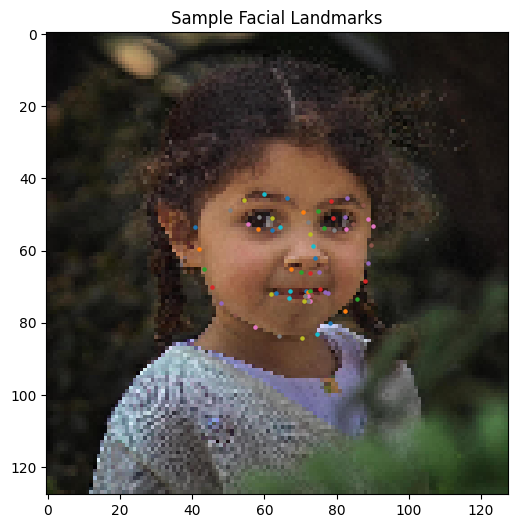

Number of Landmark Points: 68


In [24]:
sample_img, sample_landmarks = train_dataset[0]

img = sample_img.permute(1, 2, 0).numpy()
landmarks = sample_landmarks.numpy().reshape(-1, 2)

plt.figure(figsize=(6,6))
plt.imshow(img)

for (x, y) in landmarks:
    plt.scatter(x * IMG_SIZE, y * IMG_SIZE, s=5)

plt.title("Sample Facial Landmarks")
plt.show()

print("Number of Landmark Points:", len(landmarks))

In [26]:
class HRBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(HRBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        return x

In [27]:
class SimpleHRNetV2(nn.Module):
    def __init__(self, num_landmarks):
        super(SimpleHRNetV2, self).__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # HR Stages
        self.stage1 = HRBlock(32, 64)
        self.stage2 = HRBlock(64, 128)
        self.stage3 = HRBlock(128, 128)

        # Final pooling
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        # Landmark regression head
        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_landmarks * 2)
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [28]:
NUM_LANDMARKS = len(train_dataset[0][1]) // 2
model = SimpleHRNetV2(NUM_LANDMARKS).to(DEVICE)
print(model)
print("Total Landmarks:", NUM_LANDMARKS)

SimpleHRNetV2(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (stage1): HRBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (stage2): HRBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (stag

In [29]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0

    for images, landmarks in tqdm(loader):
        images = images.to(device)
        landmarks = landmarks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, landmarks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [32]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for images, landmarks in loader:

            images = images.to(device)
            landmarks = landmarks.to(device)

            outputs = model(images)

            loss = criterion(outputs, landmarks)

            running_loss += loss.item()

    return running_loss / len(loader)

In [33]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_hrnetv2_landmarks.pth")
        print("Best Model Saved!")


Epoch [1/20]


100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


Train Loss: 0.007951
Val Loss:   0.008128
Best Model Saved!

Epoch [2/20]


100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


Train Loss: 0.007899
Val Loss:   0.007952
Best Model Saved!

Epoch [3/20]


...

Train Loss: 0.007479
Val Loss:   0.007744

Epoch [19/20]


100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


Train Loss: 0.007304
Val Loss:   0.007026

Epoch [20/20]


100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


Train Loss: 0.007347
Val Loss:   0.007375


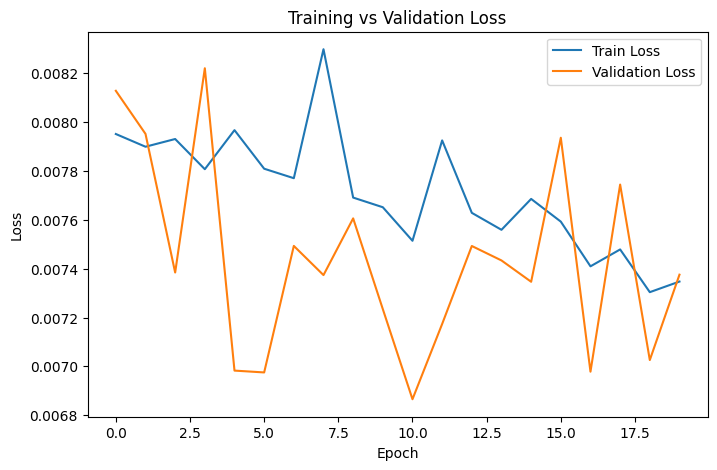

In [34]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [35]:
model.load_state_dict(torch.load("best_hrnetv2_landmarks.pth"))
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


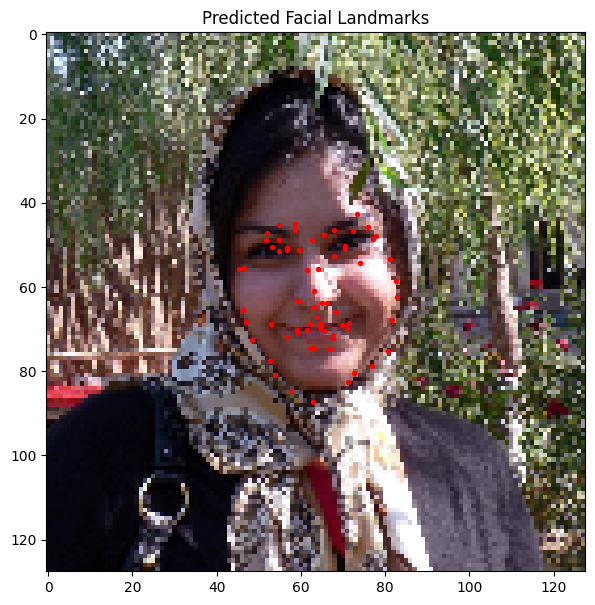

In [36]:
sample_img, true_landmarks = val_dataset[0]

input_img = sample_img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_landmarks = model(input_img)

pred_landmarks = pred_landmarks.cpu().numpy().reshape(-1, 2)

img = sample_img.permute(1, 2, 0).numpy()

plt.figure(figsize=(7,7))
plt.imshow(img)

# Predicted landmarks in RED
for (x, y) in pred_landmarks:
    plt.scatter(x * IMG_SIZE, y * IMG_SIZE, c='red', s=8)

plt.title("Predicted Facial Landmarks")
plt.show()

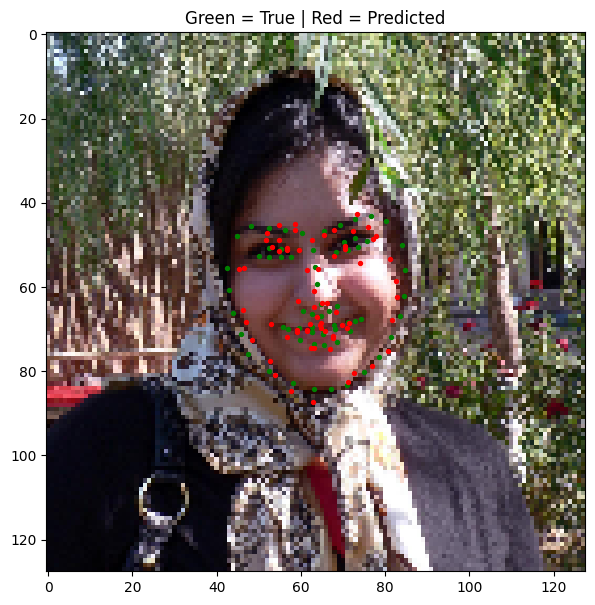

In [37]:
true_landmarks = true_landmarks.numpy().reshape(-1, 2)

plt.figure(figsize=(7,7))
plt.imshow(img)
for (x, y) in true_landmarks:
    plt.scatter(x * IMG_SIZE, y * IMG_SIZE, c='green', s=8)

# Prediction = Red
for (x, y) in pred_landmarks:
    plt.scatter(x * IMG_SIZE, y * IMG_SIZE, c='red', s=8)

plt.title("Green = True | Red = Predicted")
plt.show()